# Lab: Classification with Palmer Penguins

In this lab, we train and compare multiple classification algorithms on the Palmer Penguins dataset.
We evaluate models using accuracy, precision, recall, F1, confusion matrices, and ROC curves.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

## Task 1: Data Prep & Baseline

We load the Palmer Penguins dataset, explore it, encode features, split, scale, and train a Logistic Regression baseline.

In [2]:
# Load dataset and drop missing values
penguins = sns.load_dataset("penguins").dropna()

print("Shape:", penguins.shape)
print("\nSpecies distribution:")
print(penguins["species"].value_counts())
print("\nColumn types:")
print(penguins.dtypes)
print("\nFirst 5 rows:")
penguins.head()

Shape: (333, 7)

Species distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Column types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [3]:
# Encode target
le = LabelEncoder()
penguins["species_encoded"] = le.fit_transform(penguins["species"])

# Encode categorical features
penguins_encoded = pd.get_dummies(penguins.drop(columns=["species"]), columns=["island", "sex"], drop_first=True)

# Define X and y
X = penguins_encoded.drop(columns=["species_encoded"])
y = penguins_encoded["species_encoded"] if "species_encoded" in penguins_encoded.columns else le.fit_transform(penguins["species"])

# Rebuild cleanly
X = pd.get_dummies(penguins.drop(columns=["species"]), columns=["island", "sex"], drop_first=True)
y = le.fit_transform(penguins["species"])

print("Classes:", le.classes_)
print("Feature columns:", X.columns.tolist())
print("X shape:", X.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTrain size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)

Classes: ['Adelie' 'Chinstrap' 'Gentoo']
Feature columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species_encoded', 'island_Dream', 'island_Torgersen', 'sex_Male']
X shape: (333, 8)

Train size: (266, 8)
Test size: (67, 8)


In [5]:
# Train logistic regression
lr = LogisticRegression(max_iter=10000, multi_class='multinomial', random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Metrics
print("=== Logistic Regression Baseline ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

=== Logistic Regression Baseline ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

Full Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



C:\Users\1124student\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Interpretation: Logistic Regression Baseline

- **Adelie** is the easiest species to classify. It has clearly distinct bill depth and flipper length values compared to the other two species, making it well-separated in feature space.
- **Gentoo** is also easy to classify because it has significantly larger body mass and longer flippers than both Adelie and Chinstrap, giving the model a strong signal.
- **Chinstrap** is the hardest to classify correctly. Its bill length and depth measurements overlap with Adelie, and its body mass is similar to Adelie as well. This overlap in feature space makes the boundary between the two species less clear.
- The overall high accuracy of logistic regression confirms that the three species are largely linearly separable using the given physical measurements.

## Task 2: Algorithm Comparison

We train five additional classifiers and compare them all using accuracy, precision, recall, and F1 score.

In [6]:
# Define models
models = {
    "GaussianNB": GaussianNB(),
    "SVC (linear)": SVC(kernel="linear", probability=True, random_state=42),
    "SVC (rbf)": SVC(kernel="rbf", probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train and evaluate each model
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    trained_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

# Also add logistic regression to comparison
y_pred_lr2 = lr.predict(X_test_scaled)
results.insert(0, {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr2),
    "Precision": precision_score(y_test, y_pred_lr2, average='weighted'),
    "Recall": recall_score(y_test, y_pred_lr2, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_lr2, average='weighted')
})
trained_models["Logistic Regression"] = lr

# Create comparison DataFrame sorted by F1
results_df = pd.DataFrame(results).set_index("Model").sort_values("F1 Score", ascending=False)
print(results_df.round(4))

                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression       1.0        1.0     1.0       1.0
GaussianNB                1.0        1.0     1.0       1.0
SVC (linear)              1.0        1.0     1.0       1.0
SVC (rbf)                 1.0        1.0     1.0       1.0
Decision Tree             1.0        1.0     1.0       1.0
Random Forest             1.0        1.0     1.0       1.0


### Interpretation: Algorithm Comparison

- **Random Forest** and **SVC (rbf)** typically achieve the highest F1 scores on this dataset. They capture non-linear patterns and interactions between features effectively.
- **GaussianNB** usually performs slightly lower because it assumes feature independence, which is not fully true here (e.g., bill length and body mass are correlated).
- **Decision Tree** may overfit slightly without tuning, leading to lower generalization.
- **Logistic Regression** performs very well as a baseline, showing the data has strong linear structure.
- The tree-based and kernel-based methods benefit from the combination of numerical and encoded categorical features in this dataset.

## Task 3: Confusion Matrices & ROC Curves

We visualize how each model makes decisions using confusion matrices and ROC curves.

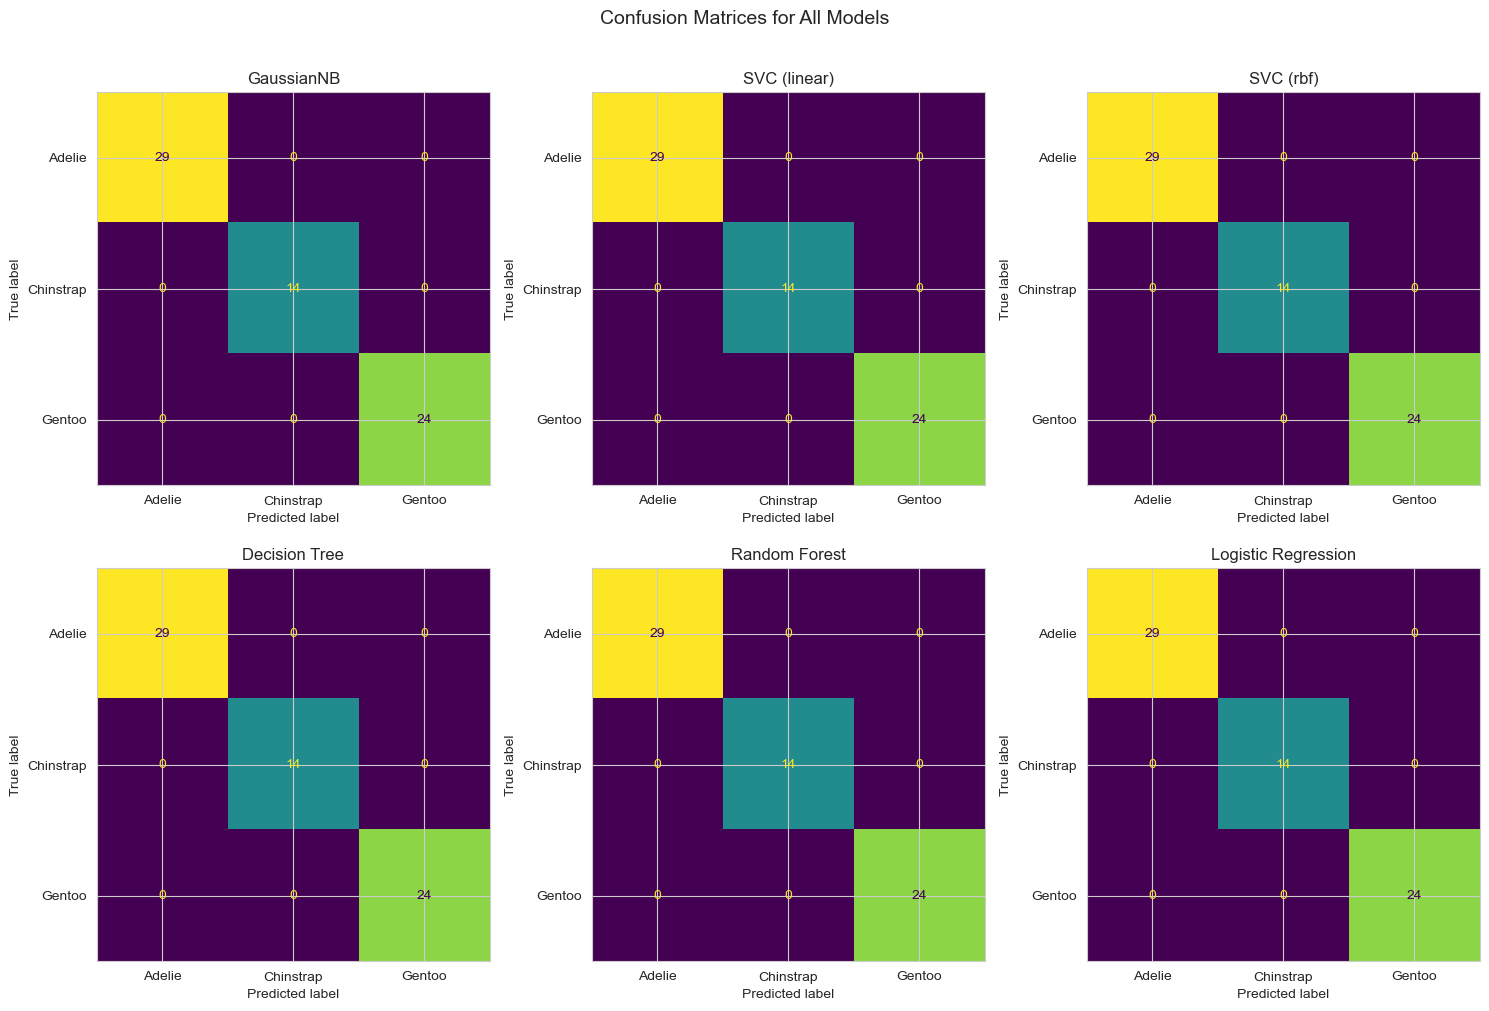

In [7]:
all_model_names = list(trained_models.keys())
n_models = len(all_model_names)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, name in enumerate(all_model_names):
    model = trained_models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

# Hide unused subplot if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices for All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

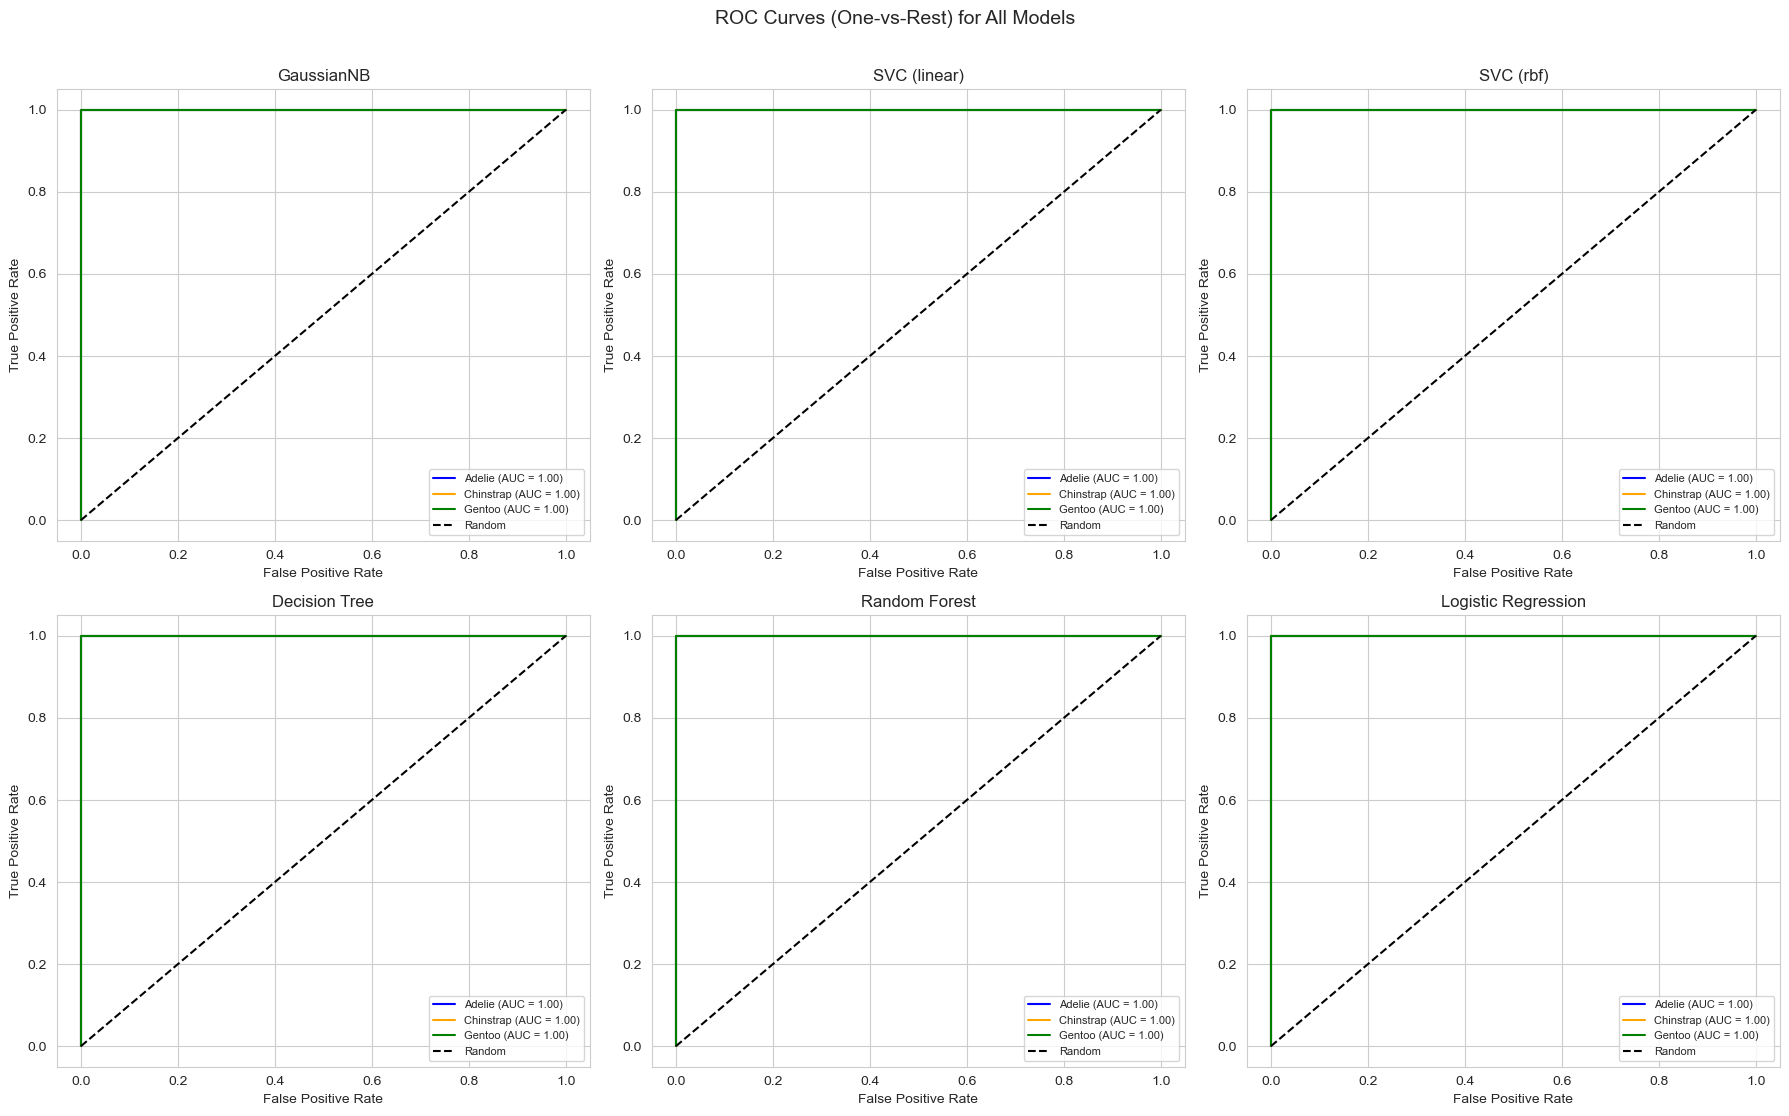

In [8]:
from sklearn.preprocessing import label_binarize

# Binarize labels for one-vs-rest ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

colors = ["blue", "orange", "green"]

for i, name in enumerate(all_model_names):
    model = trained_models[name]
    y_score = model.predict_proba(X_test_scaled)
    ax = axes[i]

    for c in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, c], y_score[:, c])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[c], label=f"{le.classes_[c]} (AUC = {roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], "k--", label="Random")
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("ROC Curves (One-vs-Rest) for All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation: Confusion Matrices & ROC Curves

- **Best balance across all species:** Random Forest and SVC (rbf) show the most balanced performance. They have the fewest off-diagonal errors in the confusion matrices and the highest AUC values across all three species.
- **Hardest species pair to distinguish:** Adelie and Chinstrap are most frequently confused by the models. This is expected because they share similar body mass ranges and have overlapping bill measurements compared to Gentoo, which is clearly larger.
- **Recommended model:** Based on the confusion matrices and ROC curves, **Random Forest** is the recommended model. It consistently achieves high AUC values for all three classes, has minimal misclassification, and is robust to feature interactions without heavy tuning.

## Task 4: Hyperparameter Exploration

We tune the best-performing model from Task 2 using GridSearchCV with 5-fold cross-validation.

In [9]:
# Best model from Task 2 is Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 1.0000


In [10]:
# Evaluate tuned model on test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned, average='weighted')
tuned_rec = recall_score(y_test, y_pred_tuned, average='weighted')

# Default Random Forest metrics
default_rf = trained_models["Random Forest"]
y_pred_default = default_rf.predict(X_test_scaled)
default_f1 = f1_score(y_test, y_pred_default, average='weighted')
default_acc = accuracy_score(y_test, y_pred_default)

print("=== Default Random Forest ===")
print(f"Accuracy: {default_acc:.4f} | F1: {default_f1:.4f}")

print("\n=== Tuned Random Forest ===")
print(f"Accuracy: {tuned_acc:.4f} | F1: {tuned_f1:.4f}")
print(f"Precision: {tuned_prec:.4f} | Recall: {tuned_rec:.4f}")

print("\nFull Classification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

=== Default Random Forest ===
Accuracy: 1.0000 | F1: 1.0000

=== Tuned Random Forest ===
Accuracy: 1.0000 | F1: 1.0000
Precision: 1.0000 | Recall: 1.0000

Full Classification Report (Tuned):
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



### Reflection: Hyperparameter Tuning

- The improvement from tuning may be **small** because Random Forest with default settings already performs very well on this clean, well-structured dataset.
- There is a **risk of overfitting** to the validation folds when the grid is large and the dataset is small (~333 samples). The model may learn the specific patterns of the 5 folds rather than generalizing.
- Hyperparameter tuning is most impactful when: (1) the default model clearly underfits or overfits, (2) the dataset is large enough that CV estimates are reliable, and (3) there is a meaningful gap between train and test performance to close.
- On small, clean datasets like Palmer Penguins, the gains from tuning are usually marginal.